# Real Performance Comparison

Compares Performance of `RazorsEdgeGPUBenchmarkTask` with `BaseBatchedGPUBenchmarkTask` with different batch sizes.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()

while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import asyncio
import time
import matplotlib.pyplot as plt
from src.executor.process_manager import ComputeExecutor
from demos.real.razors_edge_gpu_benchmark_task import RazorsEdgeGPUBenchmarkTask
from demos.real.base_batched_gpu_benchmark_task_variants import BaseBatchedGPUBenchmarkTask, BaseBatchedGPUBenchmarkTaskB2, BaseBatchedGPUBenchmarkTaskB8, BaseBatchedGPUBenchmarkTaskB10, BaseBatchedGPUBenchmarkTaskB13, BaseBatchedGPUBenchmarkTaskB16


## Start executor

In [3]:
executor = ComputeExecutor(
    [RazorsEdgeGPUBenchmarkTask, BaseBatchedGPUBenchmarkTask, BaseBatchedGPUBenchmarkTaskB2, BaseBatchedGPUBenchmarkTaskB8, BaseBatchedGPUBenchmarkTaskB10, BaseBatchedGPUBenchmarkTaskB13, BaseBatchedGPUBenchmarkTaskB16],
    async_limit=64,
    model_thread_limit=1,
)


## Basic functionality check

In [4]:
sample = executor.sync_compute_fn(RazorsEdgeGPUBenchmarkTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 1 passed")

sample = executor.sync_compute_fn(BaseBatchedGPUBenchmarkTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 2 passed")


sync check 1 passed
sync check 2 passed


## Benchmark helpers

In [5]:
import random
import string

def generate_random_strings(n, a, b, seed=42):
    random.seed(seed)  # set seed for reproducibility
    chars = string.ascii_letters + string.digits  # a-z, A-Z, 0-9
    result = []
    for _ in range(n):
        length = random.randint(a, b)
        rand_str = ''.join(random.choice(chars) for _ in range(length))
        result.append(rand_str)
    return result

async def benchmark_async(target, max_token_count: int, request_count: int) -> tuple[float, float]:
    payloads = generate_random_strings(request_count, 1, max_token_count)
    start = time.perf_counter()

    await asyncio.gather(
        *(executor.async_compute_fn(target, payload) for payload in payloads)
    )
    elapsed = time.perf_counter() - start
    
    return elapsed, request_count / elapsed


## Run timing benchmarks

In [6]:
max_string_size = 500  # checked with demos\real\tokenizer_test.ipynb
n_req = 200
tasks = [RazorsEdgeGPUBenchmarkTask, BaseBatchedGPUBenchmarkTask, BaseBatchedGPUBenchmarkTaskB2, BaseBatchedGPUBenchmarkTaskB8, BaseBatchedGPUBenchmarkTaskB10, BaseBatchedGPUBenchmarkTaskB13, BaseBatchedGPUBenchmarkTaskB16]

rps_list = []
for task in tasks:
    a_elapsed, a_rps = await benchmark_async(task, max_string_size, n_req)
    rps_list.append(a_rps)
    print(f"Completeded one benchmark for {task.__name__}", a_rps)

Completeded one benchmark for RazorsEdgeGPUBenchmarkTask 85.17852737863177
Completeded one benchmark for BaseBatchedGPUBenchmarkTask 39.92961765993999
Completeded one benchmark for BaseBatchedGPUBenchmarkTaskB2 52.508092350397334
Completeded one benchmark for BaseBatchedGPUBenchmarkTaskB8 61.98759696367562
Completeded one benchmark for BaseBatchedGPUBenchmarkTaskB10 66.53748856855746
Completeded one benchmark for BaseBatchedGPUBenchmarkTaskB13 64.31922506131002
Completeded one benchmark for BaseBatchedGPUBenchmarkTaskB16 64.70142556624688


## Matplotlib diagram 1: Throughput vs Load (Parallelism Limit)

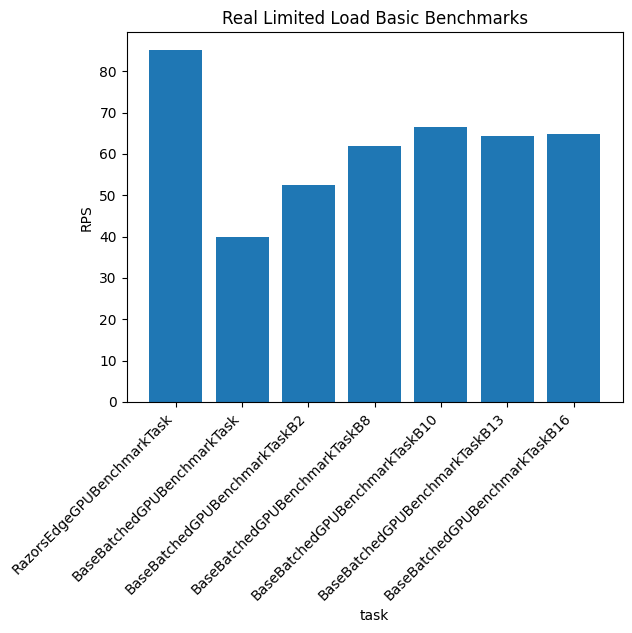

In [7]:
plt.bar([i.__name__ for i in tasks], rps_list)
plt.ylabel("RPS")
plt.xticks(rotation=45, ha='right')
plt.xlabel("task")
plt.title("Real Limited Load Basic Benchmarks")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches='tight')
plt.show()